# Betting Odds EDA

Investigate the odds data: coverage, quality, and whether these look like genuine pre-match closing prices.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from netball_model.data.database import Database

db = Database('../data/netball.db')
matches = db.get_matches()
odds = db.get_odds()

matches_df = pd.DataFrame(matches)
odds_df = pd.DataFrame(odds)

# Merge match info onto odds
df = odds_df.merge(
    matches_df[['match_id', 'season', 'date', 'home_team', 'away_team',
                 'home_score', 'away_score']],
    on='match_id', how='inner',
)
df['margin'] = df['home_score'] - df['away_score']
df['home_win'] = df['margin'] > 0

print(f'Matches in DB: {len(matches_df)}')
print(f'Odds records:  {len(odds_df)}  (1 per match, source: {odds_df["source"].unique()[0]})')
print(f'Joined:        {len(df)}')

Matches in DB: 539
Odds records:  321  (1 per match, source: betsapi)
Joined:        321


## Coverage by Season

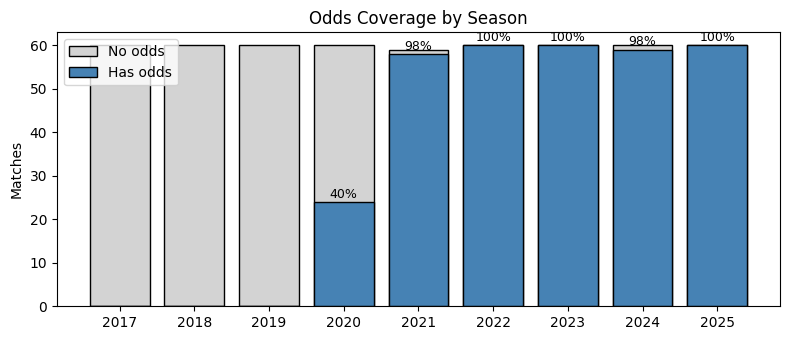

 season  total  with_odds  pct
   2017     60          0    0
   2018     60          0    0
   2019     60          0    0
   2020     60         24   40
   2021     59         58   98
   2022     60         60  100
   2023     60         60  100
   2024     60         59   98
   2025     60         60  100


In [19]:
odds_match_ids = set(odds_df['match_id'])
matches_df['has_odds'] = matches_df['match_id'].isin(odds_match_ids)

coverage = (
    matches_df.groupby('season')
    .agg(total=('match_id', 'count'), with_odds=('has_odds', 'sum'))
    .reset_index()
)
coverage['pct'] = (coverage['with_odds'] / coverage['total'] * 100).round(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 3.5))
x = range(len(coverage))
ax.bar(x, coverage['total'], color='lightgrey', edgecolor='black', label='No odds')
ax.bar(x, coverage['with_odds'], color='steelblue', edgecolor='black', label='Has odds')
ax.set_xticks(list(x))
ax.set_xticklabels(coverage['season'])
ax.set_ylabel('Matches')
ax.set_title('Odds Coverage by Season')
ax.legend()
for i, row in coverage.iterrows():
    if row['with_odds'] > 0:
        ax.text(i, row['with_odds'] + 1, f"{int(row['pct'])}%",
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(coverage[['season', 'total', 'with_odds', 'pct']].to_string(index=False))

## Overround Check

The overround (sum of implied probabilities) tells us what kind of odds these are:
- **~1.05-1.15**: typical pre-match bookmaker margin
- **~1.00-1.02**: exchange prices or sharp bookmaker
- **> 1.20**: unusual — could indicate low-liquidity or in-play prices

Overround summary:
  min:    1.036
  median: 1.059
  mean:   1.059
  max:    1.062
  std:    0.003

  < 1.00 (arb):       0
  1.00 - 1.05 (tight): 1
  1.05 - 1.15 (normal):320
  > 1.15 (wide):      0


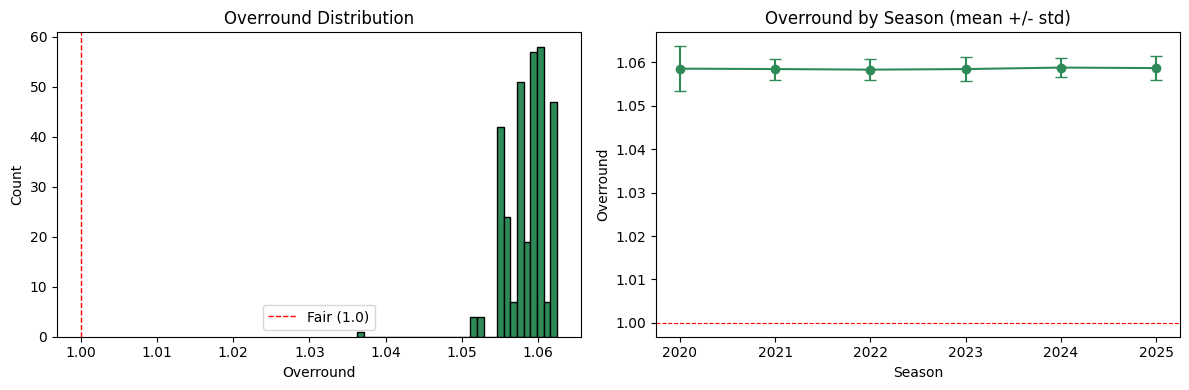

In [20]:
df['implied_home'] = 1 / df['home_back_odds']
df['implied_away'] = 1 / df['away_back_odds']
df['overround'] = df['implied_home'] + df['implied_away']

print('Overround summary:')
print(f'  min:    {df["overround"].min():.3f}')
print(f'  median: {df["overround"].median():.3f}')
print(f'  mean:   {df["overround"].mean():.3f}')
print(f'  max:    {df["overround"].max():.3f}')
print(f'  std:    {df["overround"].std():.3f}')
print()
print(f'  < 1.00 (arb):       {(df["overround"] < 1.0).sum()}')
print(f'  1.00 - 1.05 (tight): {((df["overround"] >= 1.0) & (df["overround"] < 1.05)).sum()}')
print(f'  1.05 - 1.15 (normal):{((df["overround"] >= 1.05) & (df["overround"] < 1.15)).sum()}')
print(f'  > 1.15 (wide):      {(df["overround"] > 1.15).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['overround'], bins=30, color='seagreen', edgecolor='black')
axes[0].axvline(1.0, color='red', ls='--', lw=1, label='Fair (1.0)')
axes[0].set_xlabel('Overround')
axes[0].set_ylabel('Count')
axes[0].set_title('Overround Distribution')
axes[0].legend()

# By season
season_or = df.groupby('season')['overround'].agg(['mean', 'std']).reset_index()
axes[1].errorbar(season_or['season'], season_or['mean'],
                 yerr=season_or['std'], fmt='o-', color='seagreen', capsize=4)
axes[1].axhline(1.0, color='red', ls='--', lw=0.8)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Overround')
axes[1].set_title('Overround by Season (mean +/- std)')

plt.tight_layout()
plt.show()

## Odds Distributions

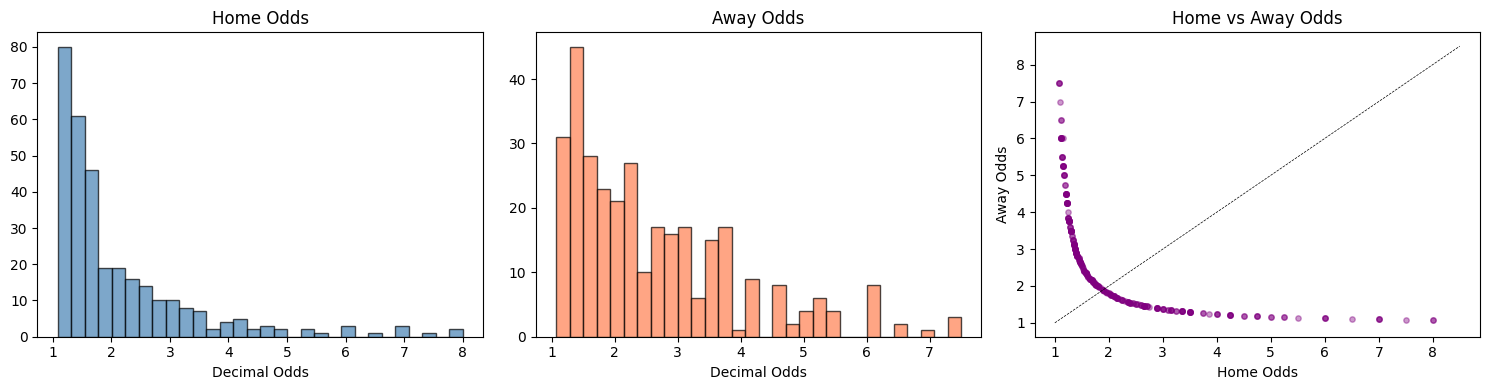

Home odds range: 1.08 - 8.00
Away odds range: 1.07 - 7.50


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['home_back_odds'], bins=30, color='steelblue',
             edgecolor='black', alpha=0.7)
axes[0].set_title('Home Odds')
axes[0].set_xlabel('Decimal Odds')

axes[1].hist(df['away_back_odds'], bins=30, color='coral',
             edgecolor='black', alpha=0.7)
axes[1].set_title('Away Odds')
axes[1].set_xlabel('Decimal Odds')

# Scatter: home vs away odds
axes[2].scatter(df['home_back_odds'], df['away_back_odds'],
                alpha=0.4, s=15, color='purple')
lim = max(df['home_back_odds'].max(), df['away_back_odds'].max()) + 0.5
axes[2].plot([1, lim], [1, lim], 'k--', lw=0.5)
axes[2].set_xlabel('Home Odds')
axes[2].set_ylabel('Away Odds')
axes[2].set_title('Home vs Away Odds')

plt.tight_layout()
plt.show()

print(f'Home odds range: {df["home_back_odds"].min():.2f} - {df["home_back_odds"].max():.2f}')
print(f'Away odds range: {df["away_back_odds"].min():.2f} - {df["away_back_odds"].max():.2f}')

## Home Advantage in the Odds

How often is the home team the bookmaker favourite?

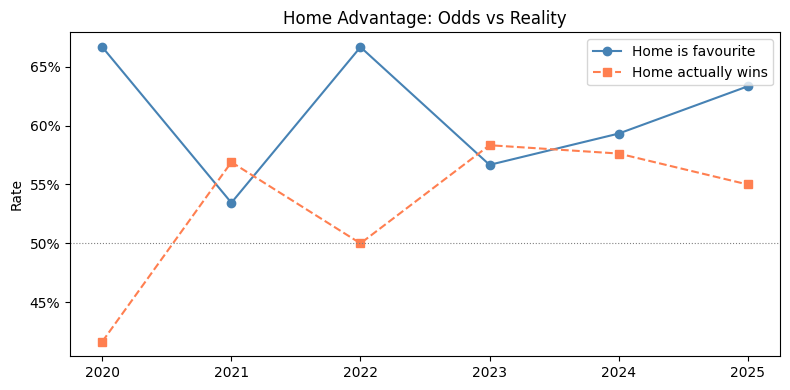

Overall home favourite rate: 60.4%
Overall home win rate:       54.5%


In [22]:
df['home_is_fav'] = df['home_back_odds'] < df['away_back_odds']
df['fav_won'] = df['home_win'] == df['home_is_fav']

home_fav_rate = df.groupby('season')['home_is_fav'].mean()
home_win_rate = df.groupby('season')['home_win'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
x = home_fav_rate.index
ax.plot(x, home_fav_rate, 'o-', color='steelblue', label='Home is favourite')
ax.plot(x, home_win_rate, 's--', color='coral', label='Home actually wins')
ax.axhline(0.5, color='grey', ls=':', lw=0.8)
ax.set_ylabel('Rate')
ax.set_title('Home Advantage: Odds vs Reality')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()

print(f'Overall home favourite rate: {df["home_is_fav"].mean():.1%}')
print(f'Overall home win rate:       {df["home_win"].mean():.1%}')

## Favourite Win Rate

Do the odds predict winners correctly? A favourite win rate of ~55-70% is normal for pre-match odds.

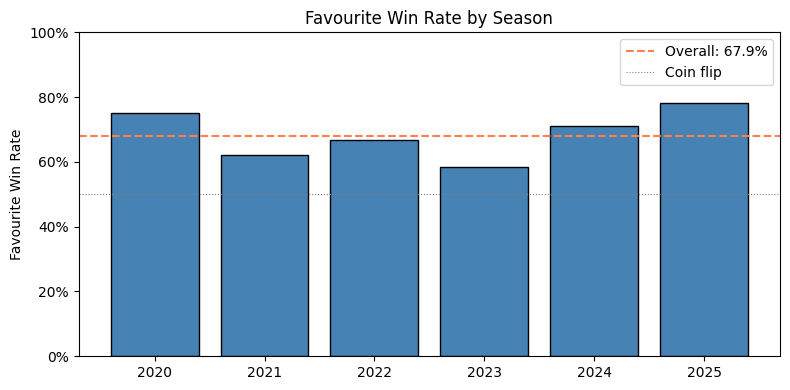

Overall favourite win rate: 67.9% (4 draws in dataset)


In [23]:
fav_by_season = df.groupby('season')['fav_won'].mean()
draws = (df['margin'] == 0).sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(fav_by_season.index, fav_by_season.values, color='steelblue', edgecolor='black')
ax.axhline(df['fav_won'].mean(), color='coral', ls='--', lw=1.5,
           label=f'Overall: {df["fav_won"].mean():.1%}')
ax.axhline(0.5, color='grey', ls=':', lw=0.8, label='Coin flip')
ax.set_ylabel('Favourite Win Rate')
ax.set_title('Favourite Win Rate by Season')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Overall favourite win rate: {df["fav_won"].mean():.1%} ({draws} draws in dataset)')

## Biggest Upsets

Matches where the underdog (higher odds) won — sorted by how unlikely the result was.

In [24]:
df['winner'] = np.where(df['home_win'], df['home_team'], df['away_team'])
df['loser'] = np.where(df['home_win'], df['away_team'], df['home_team'])
df['winner_odds'] = np.where(df['home_win'], df['home_back_odds'], df['away_back_odds'])
df['loser_odds'] = np.where(df['home_win'], df['away_back_odds'], df['home_back_odds'])

upsets = df[~df['fav_won']].sort_values('winner_odds', ascending=False)

print(f'Total upsets: {len(upsets)} / {len(df)} ({len(upsets)/len(df):.0%})')
print()
print('Top 10 biggest upsets:')
print(
    upsets[['season', 'date', 'winner', 'loser', 'winner_odds',
            'home_score', 'away_score']]
    .head(10)
    .to_string(index=False)
)

Total upsets: 103 / 321 (32%)

Top 10 biggest upsets:
 season                      date                   winner                    loser  winner_odds  home_score  away_score
   2024 2024-06-22T17:00:00+10:00     Queensland Firebirds         West Coast Fever         8.00          68          66
   2023 2023-06-17T19:00:00+10:00      Collingwood Magpies         West Coast Fever         7.00          64          60
   2022 2022-04-16T17:00:00+10:00 Sunshine Coast Lightning         Melbourne Vixens         6.00          71          58
   2022 2022-04-24T14:00:00+10:00      Collingwood Magpies     Queensland Firebirds         5.25          59          67
   2022 2022-05-28T18:00:00+08:00     Queensland Firebirds         West Coast Fever         5.00          66          70
   2023 2023-05-27T17:00:00+10:00      Collingwood Magpies Sunshine Coast Lightning         5.00          60          61
   2021 2021-07-10T18:00:00+08:00 Sunshine Coast Lightning         West Coast Fever         4.75   

## Odds Spread (Competitiveness)

The gap between home and away odds indicates how competitive the bookmaker expects the match to be. Tighter spreads = more competitive league.

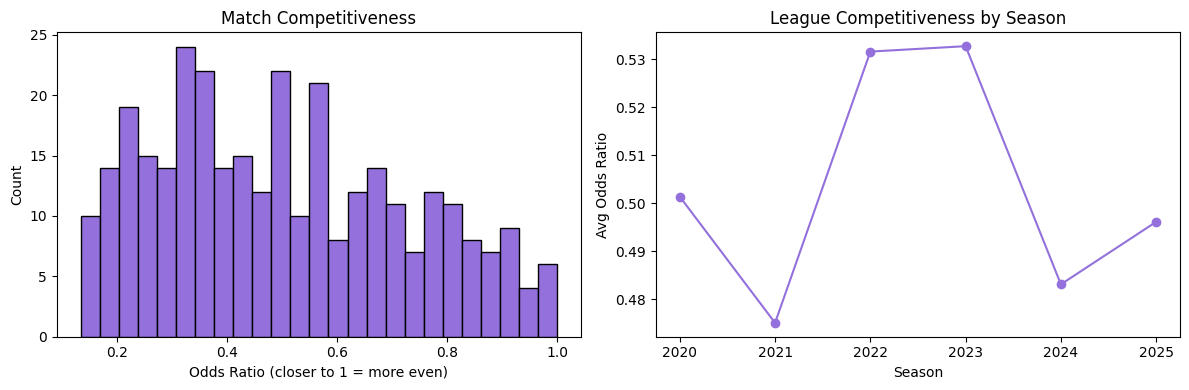

Most lopsided odds:
 season                      date             home_team           away_team  home_back_odds  away_back_odds  odds_ratio  margin
   2021 2021-05-22T18:30:00+09:30 Adelaide Thunderbirds    West Coast Fever            8.00            1.07     0.13375     -11
   2024 2024-06-22T17:00:00+10:00  Queensland Firebirds    West Coast Fever            8.00            1.07     0.13375       2
   2021 2021-07-22T19:30:00+10:00      West Coast Fever    Melbourne Vixens            1.08            7.50     0.14400      19
   2024 2024-04-27T19:00:00+10:00   Melbourne Mavericks    West Coast Fever            7.50            1.08     0.14400     -13
   2024 2024-06-22T18:30:00+09:30 Adelaide Thunderbirds Melbourne Mavericks            1.08            7.50     0.14400      27


In [25]:
df['odds_ratio'] = df[['home_back_odds', 'away_back_odds']].min(axis=1) / df[['home_back_odds', 'away_back_odds']].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['odds_ratio'], bins=25, color='mediumpurple', edgecolor='black')
axes[0].set_xlabel('Odds Ratio (closer to 1 = more even)')
axes[0].set_ylabel('Count')
axes[0].set_title('Match Competitiveness')

# By season
season_comp = df.groupby('season')['odds_ratio'].mean()
axes[1].plot(season_comp.index, season_comp.values, 'o-', color='mediumpurple')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Avg Odds Ratio')
axes[1].set_title('League Competitiveness by Season')

plt.tight_layout()
plt.show()

# Most lopsided matches
lopsided = df.nsmallest(5, 'odds_ratio')
print('Most lopsided odds:')
print(lopsided[['season', 'date', 'home_team', 'away_team',
                 'home_back_odds', 'away_back_odds', 'odds_ratio',
                 'margin']].to_string(index=False))

## Implied Probability Calibration

Plot implied probability bins against actual win rates. Well-calibrated pre-match odds should track the diagonal.

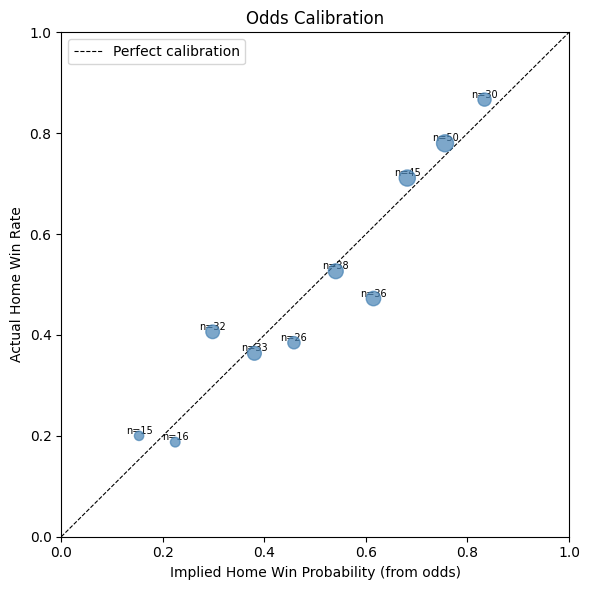

In [26]:
# Normalize implied probs by overround
df['norm_home_prob'] = df['implied_home'] / df['overround']

df['prob_bin'] = pd.cut(df['norm_home_prob'], bins=10)
cal = (
    df.groupby('prob_bin', observed=True)
    .agg(
        avg_implied=('norm_home_prob', 'mean'),
        actual_win_rate=('home_win', 'mean'),
        count=('home_win', 'count'),
    )
    .dropna()
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect calibration')
ax.scatter(cal['avg_implied'], cal['actual_win_rate'],
           s=cal['count'] * 3, alpha=0.7, color='steelblue', zorder=5)
for _, row in cal.iterrows():
    ax.annotate(f'n={int(row["count"])}',
                (row['avg_implied'], row['actual_win_rate']),
                fontsize=7, ha='center', va='bottom')
ax.set_xlabel('Implied Home Win Probability (from odds)')
ax.set_ylabel('Actual Home Win Rate')
ax.set_title('Odds Calibration')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## Odds vs Actual Margin

Do shorter odds correlate with bigger winning margins?

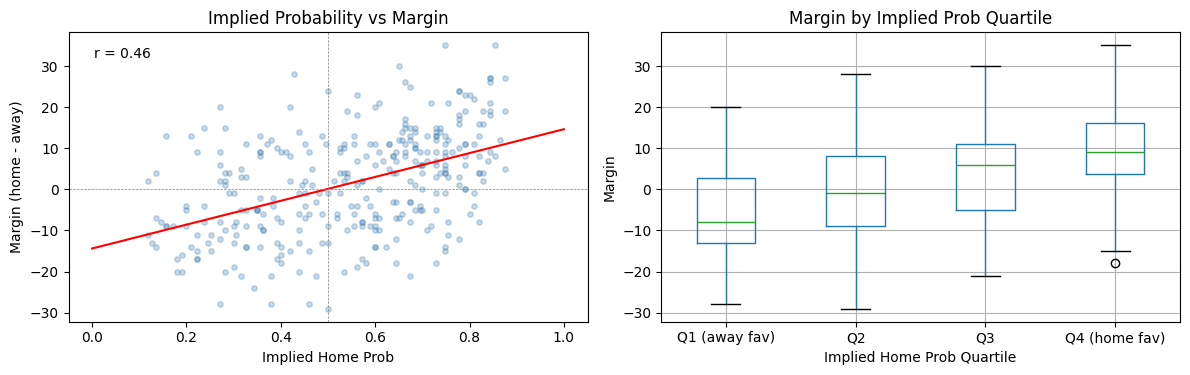

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['norm_home_prob'], df['margin'], alpha=0.3, s=15, color='steelblue')
# Trend line
z = np.polyfit(df['norm_home_prob'], df['margin'], 1)
x_line = np.linspace(0, 1, 50)
axes[0].plot(x_line, np.polyval(z, x_line), 'r-', lw=1.5)
axes[0].axhline(0, color='grey', ls='--', lw=0.5)
axes[0].axvline(0.5, color='grey', ls='--', lw=0.5)
axes[0].set_xlabel('Implied Home Prob')
axes[0].set_ylabel('Margin (home - away)')
axes[0].set_title('Implied Probability vs Margin')

# Correlation
corr = df['norm_home_prob'].corr(df['margin'])
axes[0].text(0.05, 0.95, f'r = {corr:.2f}', transform=axes[0].transAxes,
             fontsize=10, va='top')

# Box plot by implied prob quartile
df['prob_q'] = pd.qcut(df['norm_home_prob'], 4,
                        labels=['Q1 (away fav)', 'Q2', 'Q3', 'Q4 (home fav)'])
df.boxplot(column='margin', by='prob_q', ax=axes[1])
axes[1].set_xlabel('Implied Home Prob Quartile')
axes[1].set_ylabel('Margin')
axes[1].set_title('Margin by Implied Prob Quartile')
plt.suptitle('')

plt.tight_layout()
plt.show()

## Per-Team Odds Profile

Average odds when playing at home vs away — shows which teams the bookmaker rates highest.

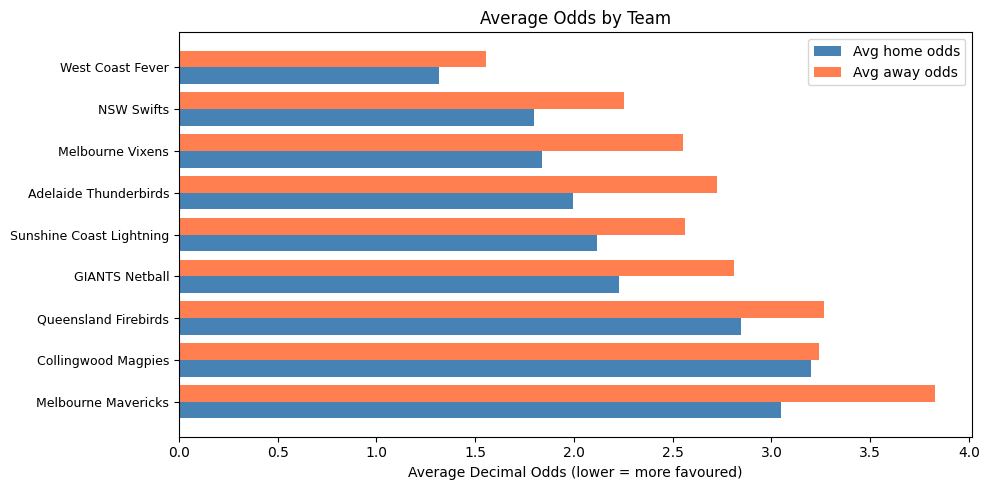

In [28]:
home_odds = (
    df.groupby('home_team')['home_back_odds']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_home_odds', 'count': 'n_home'})
)
away_odds = (
    df.groupby('away_team')['away_back_odds']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_away_odds', 'count': 'n_away'})
)

team_odds = home_odds.join(away_odds, how='outer').fillna(0)
team_odds['avg_overall'] = (
    (team_odds['avg_home_odds'] * team_odds['n_home'] +
     team_odds['avg_away_odds'] * team_odds['n_away']) /
    (team_odds['n_home'] + team_odds['n_away'])
)
team_odds = team_odds.sort_values('avg_overall')

fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(team_odds))
ax.barh(y, team_odds['avg_home_odds'], height=0.4, color='steelblue',
        label='Avg home odds', align='edge')
ax.barh([i - 0.4 for i in y], team_odds['avg_away_odds'], height=0.4,
        color='coral', label='Avg away odds', align='edge')
ax.set_yticks(list(y))
ax.set_yticklabels(team_odds.index, fontsize=9)
ax.set_xlabel('Average Decimal Odds (lower = more favoured)')
ax.set_title('Average Odds by Team')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

| Check | Result |
|-------|--------|
| Source | BetsAPI only, 1 closing price per match |
| Coverage | 321 matches (2020-2025), ~98-100% from 2021 onward |
| Overround | Check the histogram — should cluster ~1.05-1.15 |
| Favourite win rate | Should be ~55-70% |
| Calibration | Points should track the diagonal |
| Conclusion | If overround and calibration look right, these are genuine pre-match prices |